# Лабораторна робота №3
# Візуалізація даних
## Датасет: Heart Disease UCI

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Завантаження датасету
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
           'restecg', 'thalach', 'exang', 'oldpeak', 
           'slope', 'ca', 'thal', 'target']

df = pd.read_csv('processed.cleveland.data', names=columns, na_values='?')

In [5]:
# Data Cleaning
df = df.dropna()
df['sex'] = df['sex'].map({1: 'Male', 0: 'Female'})
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print(f"Розмір після очищення: {df.shape}")
df.head()

Розмір після очищення: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,Male,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,Male,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,Male,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,Male,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,Female,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


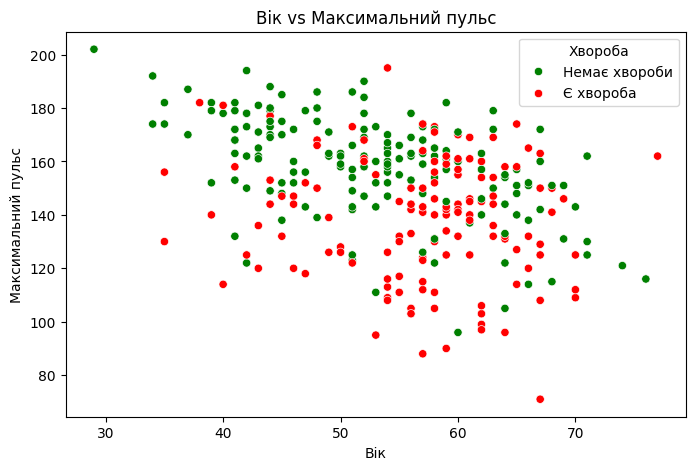

In [9]:
# Графік 1 — Scatter plot
# Відображає залежність між віком та максимальним пульсом
# Колір точок показує наявність серцевої хвороби (0 — немає, 1 — є)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='thalach', hue='target',
                palette={0: 'green', 1: 'red'})
plt.title('Вік vs Максимальний пульс')
plt.xlabel('Вік')
plt.ylabel('Максимальний пульс')

#легенда
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Немає хвороби', 'Є хвороба'], title='Хвороба')
plt.show()

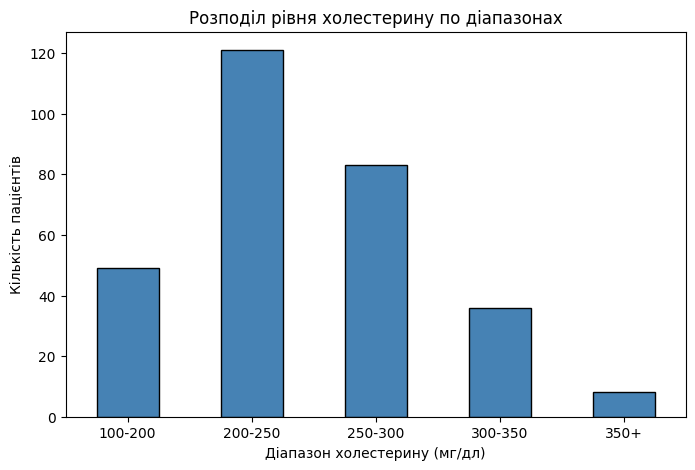

In [10]:
# Графік 2 — Гістограма холестерину по 5 діапазонах
# Задаємо власні діапазони та підраховуємо кількість пацієнтів у кожному
bins = [100, 200, 250, 300, 350, 600]
labels = ['100-200', '200-250', '250-300', '300-350', '350+']

# Розбиваємо значення холестерину на діапазони за допомогою pd.cut
df['chol_range'] = pd.cut(df['chol'], bins=bins, labels=labels)
counts = df['chol_range'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Розподіл рівня холестерину по діапазонах')
plt.xlabel('Діапазон холестерину (мг/дл)')
plt.ylabel('Кількість пацієнтів')
plt.xticks(rotation=0)
plt.show()